# Steane Multi Round fixed p (below threshold) 

Data generation and analysis:

+ different decoder: ML, MWPM
+ different distances
+ fixed noise levels
+ multiple rounds

analysis: 
+ show log error rate depend on round


In [66]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import read_config, write_config, read_folder, get_standard_config
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER


## Config Defintions and Data Generation

Steane circ (order 0p) with only multiple qec rounds (both log X and Z observable)

Circuit level noise with fixed level below threshold

Decoding both in ML and MWPM


In [67]:
# General parameter
noise_rates = [0.005,0.001,0.0005,] # Needs to be below threshold!
distances = [3,5,7,9,11,13,15] 
qec_rounds = [1,2,3,4,5,6,7,8,9]
order = "0p"
circuit_type = "steane"
noise_model_type = "circ"

# Main parameters
num_shots_ML = 1_000
decoder_type_ML = "ml"

num_shots_MWPM = 100_000
decoder_type_MWPM = "mwpm"

# Z config
observable_Z  = "Z"
init_state_Z = "0"
# X config
observable_X  = "X"
init_state_X = "p"

In [68]:
# Folder names (for writing data to file):
w_folder_name_ML_Z = "multi_round_circ_md_mr_fp_steane_Z_ML"
w_folder_name_ML_X = "multi_round_circ_md_mr_fp_steane_X_ML"
w_folder_name_MWPM_Z = "multi_round_circ_md_mr_fp_steane_Z_MWPM"
w_folder_name_MWPM_X = "multi_round_circ_md_mr_fp_steane_X_MWPM"

In [69]:
# Switches for data generation
regen_data_everything = False 

regen_data_ML = False 
regen_data_MWPM = False 


In [70]:
# ML Config (Z)
# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
write_config(config_ML_Z,w_folder_name_ML_Z,backup=True)

In [71]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_Z)

In [72]:
# ML Config (X)

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
write_config(config_ML_X,w_folder_name_ML_X,backup=True)

In [73]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_X)

In [74]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
write_config(config_MWPM_Z,w_folder_name_MWPM_Z,backup=True)

In [75]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_Z)

In [76]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
write_config(config_MWPM_X,w_folder_name_MWPM_X,backup=True)

In [77]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_X)

# Analysis

In [78]:
# Folder paths (reading in data)
r_folder_name_ML_Z = "multi_round_circ_md_mr_fp_steane_Z_ML"
r_folder_name_ML_X = "multi_round_circ_md_mr_fp_steane_X_ML"
r_folder_name_MWPM_Z = "multi_round_circ_md_mr_fp_steane_Z_MWPM"
r_folder_name_MWPM_X = "multi_round_circ_md_mr_fp_steane_X_MWPM"

In [86]:
def analysis_pipeline(
        folder_name, 
        ):

    config, data = read_folder(folder_name)
    data = data_pre_processing(data)
    distances = data["distances"]
    rounds = data["rounds"]
    log_error_rates = data["log_error_rates"]
    err_log_error_rates = data["err_log_error_rates"]
    for i_noise_rate in range(len(data["noise_rates"])):
        plt.figure()
        plt.title(f"$p={data["noise_rates"][i_noise_rate]}$")
        for i in range(len(distances)):
            plt.errorbar(
                rounds,
                log_error_rates[i,:,i_noise_rate],
                yerr=err_log_error_rates[i,:,i_noise_rate], 
                label=f"d={distances[i]}",
                )
        plt.legend()
        plt.yscale("log")
        plt.show()
    return data

### Generate analysis Data

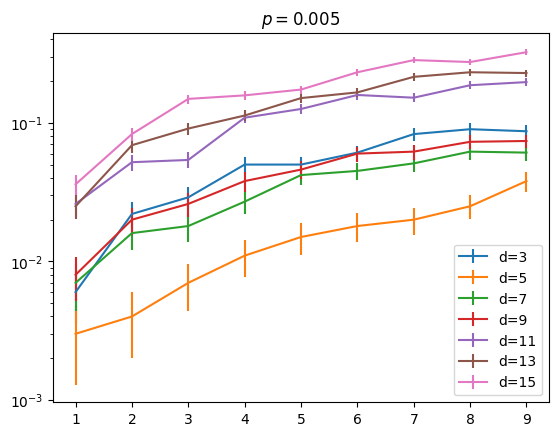

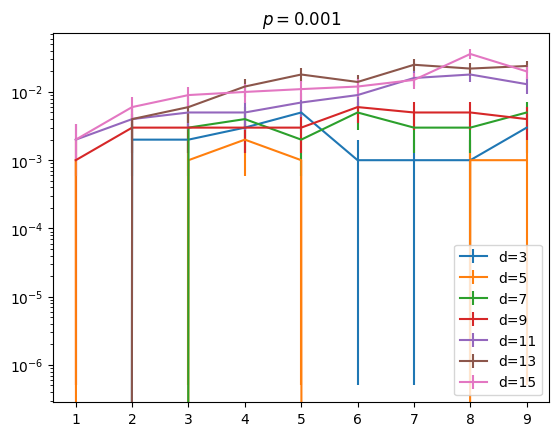

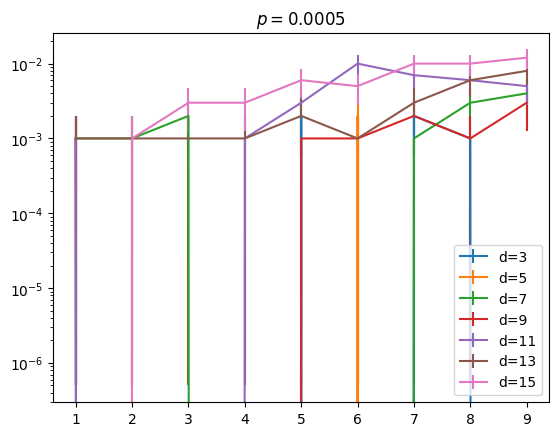

In [87]:
folder_name = r_folder_name_ML_Z

result = analysis_pipeline(
    folder_name,
    )

results_ML_Z = result

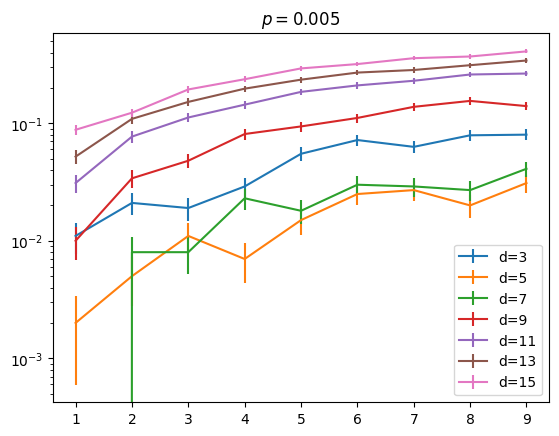

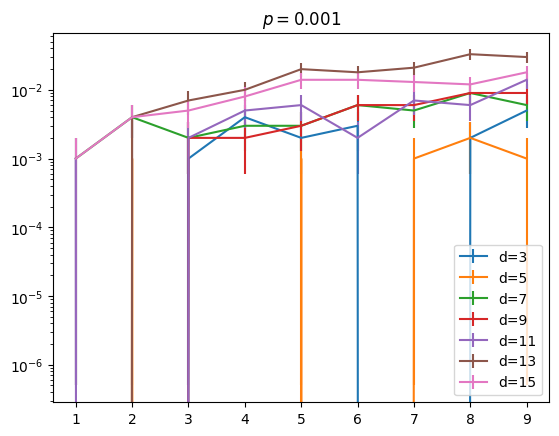

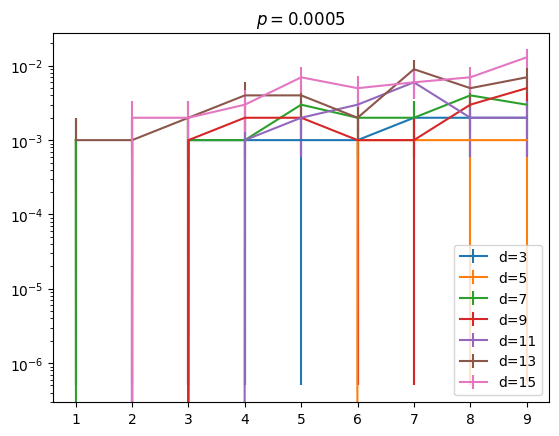

In [88]:
folder_name = r_folder_name_ML_X 

result = analysis_pipeline(
    folder_name = folder_name,
)

results_ML_X = result

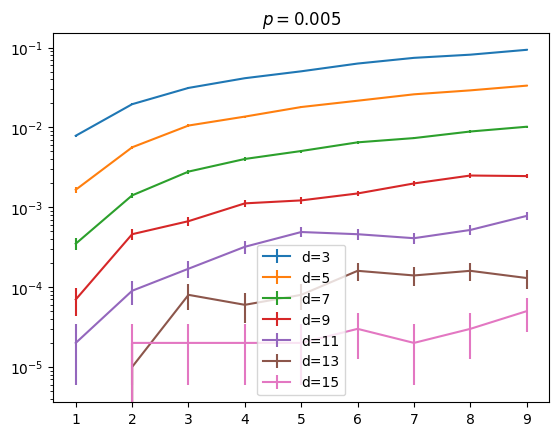

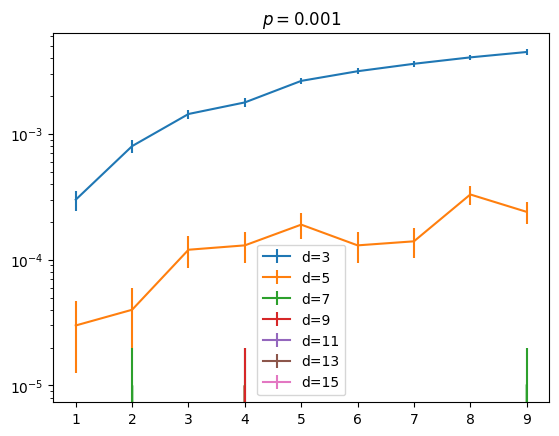

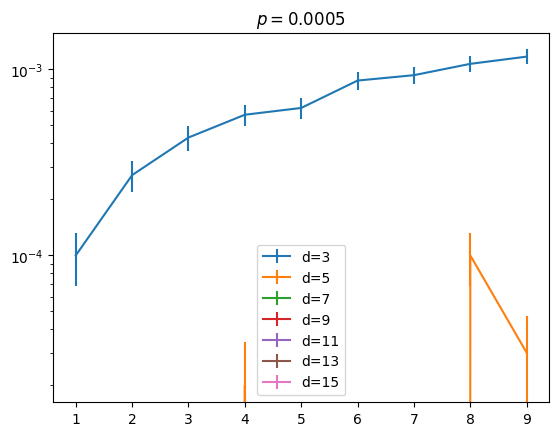

In [89]:
folder_name = r_folder_name_MWPM_Z 

result = analysis_pipeline(
    folder_name = folder_name,
    )

results_MWPM_Z= result

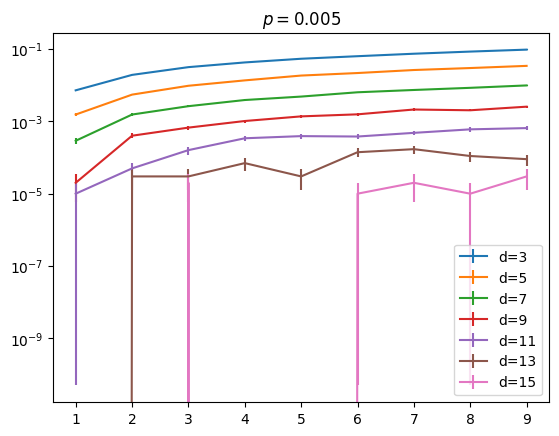

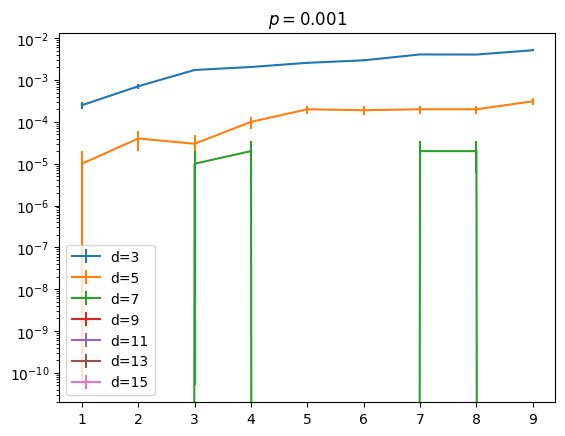

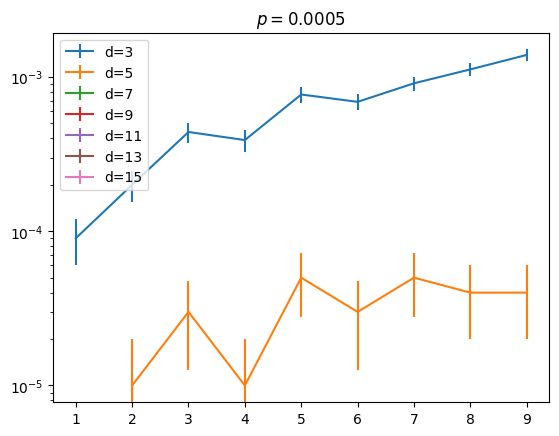

In [90]:
folder_name = r_folder_name_MWPM_X 

result = analysis_pipeline(
    folder_name = folder_name,
    )

results_MWPM_X = result